### Importing the files

In [1]:
# ingredients_kcal_master
# https://docs.google.com/spreadsheets/d/1TbOnxrXxv4nN-ATJwXl9kQAiC78q8b5tNMIPno2qvK8/edit?gid=1752466942#gid=1752466942

import pandas as pd
sheet_id = '1TbOnxrXxv4nN-ATJwXl9kQAiC78q8b5tNMIPno2qvK8'

url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'
cooked_ingred_df = pd.read_csv(url)

cooked_ingred_df.head()

,Ingredient,Kcal per 100g
0,White rice (cooked),130
1,Brown rice (cooked),123
2,"Rice (parboiled, cooked)",123
3,Pasta (cooked),158
4,Spaghetti (cooked),157


In [2]:
# fruits kcal
# https://docs.google.com/spreadsheets/d/1TbOnxrXxv4nN-ATJwXl9kQAiC78q8b5tNMIPno2qvK8/edit?gid=1824058165#gid=1824058165
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=1824058165'
fruits_kcal_df = pd.read_csv(url)

fruits_kcal_df.head()

,Ingredient,Kcal per 100g
0,Apple (fresh edible),52
1,Banana (ripe fresh),89
2,Orange (fresh edible),47
3,Pineapple (fresh edible),50
4,Mango (ripe fresh),60


In [3]:
# snacks kcal
# https://docs.google.com/spreadsheets/d/1TbOnxrXxv4nN-ATJwXl9kQAiC78q8b5tNMIPno2qvK8/edit?gid=620333892#gid=620333892
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=620333892'
snacks_kcal_df = pd.read_csv(url)
snacks_kcal_df.head()

,Ingredient,Kcal per 100g
0,Yoghurt (plain whole),61
1,Fermented milk (mala / amasi),64
2,Cheese (hard average),402
3,Bread (white wheat),265
4,Brown bread,247


In [4]:
# raw ingred kcal
# https://docs.google.com/spreadsheets/d/1TbOnxrXxv4nN-ATJwXl9kQAiC78q8b5tNMIPno2qvK8/edit?gid=0#gid=0
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=0'
raw_ingred_df = pd.read_csv(url)
raw_ingred_df

,Ingredient,Kcal per 100g
0,Maize (dry),360.0
1,Maize flour,360.0
2,Cassava (raw),160.0
3,Cassava flour (gari),350.0
4,Yam (raw),118.0
...,...,...
97,Salt,0.0
98,Water,0.0
99,Black tea (brewed),1.0
100,Coffee (brewed),2.0


In [5]:
def clean_cols(df):
    df.columns = (df.columns.str.strip().str.lower()) # normalise case
    return df

cooked_df  = clean_cols(cooked_ingred_df)
fruits_df  = clean_cols(fruits_kcal_df)
snacks_df  = clean_cols(snacks_kcal_df)
raw_df     = clean_cols(raw_ingred_df)

cooked_df["category"] = "cooked"
fruits_df["category"] = "fruits"
snacks_df["category"] = "snacks"
raw_df["category"]    = "raw"

# Joins
all_ingred_df = pd.concat(
    [cooked_ingred_df, fruits_kcal_df, snacks_kcal_df, raw_ingred_df], 
    axis='index'
    )
all_ingred_df

,ingredient,kcal per 100g,category
0,White rice (cooked),130.0,cooked
1,Brown rice (cooked),123.0,cooked
2,"Rice (parboiled, cooked)",123.0,cooked
3,Pasta (cooked),158.0,cooked
4,Spaghetti (cooked),157.0,cooked
...,...,...,...
97,Salt,0.0,raw
98,Water,0.0,raw
99,Black tea (brewed),1.0,raw
100,Coffee (brewed),2.0,raw


In [6]:
# dropping null values
all_ingred_df = all_ingred_df.dropna(subset="ingredient")
all_ingred_df.info()


<class 'pandas.DataFrame'>
Index: 191 entries, 0 to 101
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ingredient     191 non-null    str    
 1   kcal per 100g  191 non-null    float64
 2   category       191 non-null    str    
dtypes: float64(1), str(2)
memory usage: 6.0 KB


In [7]:
# checking for duplicates
print("Number of duplicate rows:", all_ingred_df.duplicated().sum())

# dataset shape
print("All Ingredients DataFrame shape:", all_ingred_df.shape)

Number of duplicate rows: 0
All Ingredients DataFrame shape: (191, 3)


Currently the all ingredients dataset has:
- No duplicates
- Has 191 entries and 3 columns

### East african recipes

In [8]:
# east african recipes
# https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=1273166354#gid=1273166354
sheet_id_recipes = '1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8'

url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=1273166354'
kenyan_df = pd.read_csv(url)
kenyan_df.head()


,country,meal_name,community,core_ingredients,recipes,cook_time,substitutes,meal_type,Notes,Source
0,Kenya,Irio,Kikuyu,"Potatoes, peas, maize, leafy greens","Boil potatoes, peas and maize → Add chopped gr...",30,Add pumpkin leaves; replace peas with beans,Main / Side,Everyday and ceremonial food,Kenya Food Composition Tables 2018
1,Kenya,Mukimo,Kikuyu,"Potatoes, maize, beans",Boil together → Mash until smooth but textured,35,Add greens or peas,Main,Ceremonial dish,FAO Indigenous Foods
2,Kenya,Njahi,Kikuyu,"Black beans, water, salt",Slow-boil njahi until soft → Serve plain or li...,90,Stew with onions,Main,Highly valued protein,Kenya FCT
3,Kenya,Njahi ya Githeri,Kikuyu,"Black beans, maize",Boil together slowly → Serve thick and hearty,100,Fry after boiling,Main,Traditional mixed meal,Ethnographic Kenya
4,Kenya,Gikuyu Thabai,Kikuyu,"Sweet potatoes, arrowroots",Boil roots together → Serve,30,Add cassava,Main,Traditional root meal,Local knowledge


In [9]:
# 2. ugandan recipes
# https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=1349696139#gid=1349696139
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=1349696139'
ugandan_df = pd.read_csv(url)

# substitutes and recipes switched
ugandan_df[["recipes", "substitutes"]] = ugandan_df[["substitutes", "recipes"]]
ugandan_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,Uganda,Matoke,"Green bananas, onion, tomato, cooking oil",Pumpkin,"Spices: Garlic,Ginger\nMethod: Steam/Stew\nSte...",Staple,National staple,FAO INFOODS Africa – https://www.fao.org/infoo...
1,Uganda,Posho,"Maize flour, water",Millet flour,Method: Boil\nSteps: Boil water → Add maize fl...,Staple,Common household food,FAO INFOODS Africa
2,Uganda,Beans Stew,"Dry beans, onion, tomato, cooking oil, salt",Cowpeas,"Method: Stew\nSteps: Boil beans → Fry onion, t...",Legume dish,Daily household meal,FAO INFOODS Africa
3,Uganda,Groundnut Stew,"Groundnuts, onion, tomato, cooking oil",Peanut paste,Method: Stew\nSteps: Fry onion → Add tomato → ...,Stew,Widely consumed,FAO Indigenous Foods of Africa – https://openk...
4,Uganda,Katogo,"Matoke, beans or meat, cooking oil",Irish potatoes,"Spices: Garlic, ginger\nMethod: Steam/Stew\nSt...",Mixed dish,Breakfast/lunch,FAO


In [10]:
# dropping the null values
ugandan_df = ugandan_df.dropna(subset="country")
ugandan_df.isna().sum()

country             0
meal_name           0
core_ingredients    0
substitutes         0
recipes             0
meal_type           0
Notes               0
Source              0
dtype: int64

In [11]:
# 3. tanzanian recipes
# https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=1454650736#gid=1454650736
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=1454650736'
tanzanian_df = pd.read_csv(url)
tanzanian_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,Tanzania,Ugali,"Maize flour, water","Sorghum flour, millet flour",Method: Boil\nSteps: Boil water → Add flour →...,Staple,National staple,FAO INFOODS Africa – https://www.fao.org/infoo...
1,Tanzania,Wali,"Rice, water, salt",Coconut rice (wali wa nazi),Method: Boil\nSteps: Boil water → Add rice → C...,Staple,Common inland & coastal,FAO INFOODS Africa
2,Tanzania,Maharage,"Dry beans, onion, tomato, cooking oil, salt",Cowpeas,"Spices: Garlic, ginger\nMethod: Stew\nSteps: B...",Legume dish,Daily household meal,FAO INFOODS Africa
3,Tanzania,Samaki wa Kupika,"Fresh fish, onion, tomato, cooking oil, salt",Dagaa,"Spices: Garlic, ginger, coriander\nMethod: Ste...",Protein dish,Widely consumed,FAO INFOODS Africa
4,Tanzania,Dagaa,"Small dried fish, onion, tomato, cooking oil",Fresh sardines,"Spices: Garlic, black pepper\nMethod: Fry/Stew...",Protein dish,Lake & coastal zones,Tanzania Food Composition Tables (FAO)


In [12]:
# ethiopian 
# https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=797769809#gid=797769809
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=797769809'
ethiopian_df = pd.read_csv(url)
ethiopian_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,Ethiopia,Injera,"Teff flour, water","Sorghum, barley",Method: Ferment/Cook\nSteps: Ferment batter → ...,Staple,National staple,FAO INFOODS Africa – https://www.fao.org/infoo...
1,Ethiopia,Shiro,"Chickpea flour, onion, garlic, oil, spices",Lentil flour,"Spices: Garlic, ginger, berbere\nMethod: Stew\...",Legume stew,Very common,FAO Indigenous Foods of Africa – https://openk...
2,Ethiopia,Misir Wot,"Red lentils, onion, garlic, oil, berbere",Yellow lentils,"Spices: Garlic, ginger, berbere\nMethod: Stew\...",Legume stew,Widely consumed,FAO Indigenous Foods of Africa
3,Ethiopia,Kik Alicha,"Yellow split peas, onion, garlic, oil",Lentils,"Spices: Garlic, ginger, berbere\nMethod: Stew\...",Legume stew,Mild stew,FAO Indigenous Foods of Africa
4,Ethiopia,Tibs,"Beef, onion, garlic, oil, spices",Goat meat,"Spices: Garlic, ginger, berbere (optional blac...",Protein dish,Home & restaurant,FAO INFOODS Africa


In [13]:
# south sudan 
# https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=902077068#gid=902077068
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=902077068'
south_sudan_df = pd.read_csv(url)
south_sudan_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,South Sudan,Kisra,"Sorghum flour, water",Millet flour,Method: Cook\nSteps: Mix sorghum flour with wa...,Staple,National staple flatbread,FAO INFOODS Africa – https://www.fao.org/infoo...
1,South Sudan,Asida,"Sorghum flour, water",Millet flour,Method: Boil\nSteps: Boil water → Slowly add s...,Staple,Thick porridge,FAO INFOODS Africa
2,South Sudan,Ful Medames,"Fava beans, onion, oil, salt",Cowpeas,Method: Stew\nSteps: Boil fava beans until sof...,Legume dish,Common breakfast,FAO Indigenous Foods of Africa – https://openk...
3,South Sudan,Bamya,"Okra, onion, tomato, oil, salt",Dried okra,Spices: Garlic\nMethod: Stew\nSteps: Fry onion...,Vegetable stew,Very common,FAO Indigenous Foods of Africa
4,South Sudan,Mulukhiyah,"Jute mallow leaves, water, salt",Pumpkin leaves,Method: Boil\nSteps: Boil water → Add chopped ...,Vegetable dish,Indigenous leafy green,FAO Indigenous Foods of Africa


In [14]:
# rwandan (https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=2033666979#gid=2033666979)
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=2033666979'
rwandan_df = pd.read_csv(url)
rwandan_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,Rwanda,Ugali (Ubugari),"Maize flour, water",Sorghum flour,Method: Boil\nSteps: Boil water → Add maize fl...,Staple,National staple,FAO INFOODS Africa – https://www.fao.org/infoo...
1,Rwanda,Isombe,"Cassava leaves, onion, oil, salt",With groundnuts,Spices: Garlic\nMethod: Stew\nSteps: Boil cass...,Vegetable dish,Very common,FAO Indigenous Foods of Africa – https://openk...
2,Rwanda,Beans Stew,"Dry beans, onion, tomato, oil, salt",Cowpeas,Spices: Garlic\nMethod: Stew\nSteps: Boil bean...,Legume dish,Daily household food,FAO INFOODS Africa
3,Rwanda,Ibihaza,"Pumpkin, beans, onion, oil",Maize,Spices: Garlic\nMethod: Stew\nSteps: Boil pump...,Mixed dish,Traditional,FAO Indigenous Foods of Africa
4,Rwanda,Sweet Potatoes,"Sweet potatoes, water",Irish potatoes,Method: Boil\nSteps: Wash and peel potatoes → ...,Staple,Widely eaten,FAO INFOODS Africa


In [15]:
# burundi(https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=1916459446#gid=1916459446)
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=1916459446'
burundi_df = pd.read_csv(url)
burundi_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,Burundi,Ugali (Ubugari),"Maize flour, water",Sorghum flour,Method: Boil\nSteps: Boil water → Add maize fl...,Staple,National staple,FAO INFOODS Africa – https://www.fao.org/infoo...
1,Burundi,Isombe,"Cassava leaves, onion, oil, salt",With groundnuts,Spices: Garlic\nMethod: Stew\nSteps: Boil cass...,Vegetable dish,Very common,FAO Indigenous Foods of Africa – https://openk...
2,Burundi,Beans Stew,"Dry beans, onion, tomato, oil",Cowpeas,Spices: Garlic\nMethod: Stew\nSteps: Boil bean...,Legume dish,Daily household meal,FAO INFOODS Africa
3,Burundi,Ibiharage,"Beans, onion, oil, salt",With maize,Spices: Garlic\nMethod: Stew\nSteps: Boil bean...,Legume dish,Staple protein,FAO
4,Burundi,Sweet Potatoes,"Sweet potatoes, water",Irish potatoes,Method: Boil\nSteps: Wash and peel → Boil unti...,Staple,Common,FAO INFOODS Africa


In [16]:
#swahili https://docs.google.com/spreadsheets/d/1KPnBS2GVQM71PCJVjNi-xl8ADznB1AMy4sPeW9jTVL8/edit?gid=1730447199#gid=1730447199
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_recipes}/export?format=csv&gid=1730447199'
swahili_df = pd.read_csv(url)
swahili_df.head()

,country,meal_name,core_ingredients,substitutes,recipes,meal_type,Notes,Source
0,Swahili,Biriani,"Rice, meat (beef/chicken), onions, garlic, gin...",Goat meat,"Spices: Garlic, ginger, cardamom, cloves, cinn...",Rice dish,Distinct from pilau,FAO INFOODS Africa – https://www.fao.org/infoo...
1,Swahili,Mchuzi wa Nazi,"Coconut milk, onion, tomato, spices",With fish or chicken,"Spices: Garlic, ginger\nMethod: Stew\nSteps: F...",Stew,Coconut-based,FAO Indigenous Foods of Africa – https://openk...
2,Swahili,Samaki wa Nazi,"Fish, coconut milk, onion, spices",Tilapia,"Spices: Garlic, ginger\nMethod: Stew\nSteps: F...",Protein dish,Coastal staple,FAO Indigenous Foods of Africa
3,Swahili,Kuku wa Nazi,"Chicken, coconut milk, onion, spices",Duck meat,"Spices: Garlic, ginger\nMethod: Stew\nSteps: F...",Protein dish,Home-style meal,FAO INFOODS Africa
4,Swahili,Maharage ya Nazi,"Beans, coconut milk, onion, salt",Cowpeas,"Spices: Garlic, ginger\nMethod: Stew\nSteps: B...",Legume dish,Common household food,FAO INFOODS Africa


### Data Joining and Cleaning

In [17]:
# extracting time from recipes
def extract_time_from_recipe(df, recipe_col="recipes"):
    # normalize column names
    df.columns = df.columns.str.strip().str.lower()
    recipe_col = recipe_col.lower()

    # make sure cook_time exists
    if "cook_time" not in df.columns:
        df["cook_time"] = pd.NA

    # fill where missing OR blank
    mask = (
        df["cook_time"].isna() |
        (df["cook_time"].astype(str).str.strip() == "")
    )

    df.loc[mask, "cook_time"] = (
        df.loc[mask, recipe_col]
          .astype(str)
          .str.extract(r"(?i)\btime\s*:\s*([^\n\r]+)", expand=False)
          .str.strip()
    )

    return df

In [18]:
ugandan_df      = extract_time_from_recipe(ugandan_df)
tanzanian_df   = extract_time_from_recipe(tanzanian_df)
ethiopian_df   = extract_time_from_recipe(ethiopian_df)
rwandan_df     = extract_time_from_recipe(rwandan_df)
burundi_df     = extract_time_from_recipe(burundi_df)
south_sudan_df = extract_time_from_recipe(south_sudan_df)
swahili_df     = extract_time_from_recipe(swahili_df)

In [19]:
# confirming the number of non-null cook_time entries extracted
for name, d in {
    "uganda": ugandan_df,
    "tanzania": tanzanian_df,
    "ethiopia": ethiopian_df,
    "rwanda": rwandan_df,
    "burundi": burundi_df,
    "south_sudan": south_sudan_df,
    "swahili": swahili_df
}.items():
    print(name, d["cook_time"].notna().sum())

uganda 15
tanzania 15
ethiopia 14
rwanda 12
burundi 12
south_sudan 12
swahili 15


In [20]:
# concatenating the east african columns
def clean_recipe_df(df, country_name):
    # normalize column names
    df.columns = df.columns.str.strip().str.lower()

    # ensure country column exists and is filled
    if "country" not in df.columns:
        df["country"] = country_name
    else:
        df["country"] = df["country"].fillna(country_name)
        df["country"] = df["country"].replace("", country_name)

    return df


kenyan_df      = clean_recipe_df(kenyan_df, "Kenya")
ugandan_df     = clean_recipe_df(ugandan_df, "Uganda")
tanzanian_df   = clean_recipe_df(tanzanian_df, "Tanzania")
ethiopian_df   = clean_recipe_df(ethiopian_df, "Ethiopia")
south_sudan_df = clean_recipe_df(south_sudan_df, "South Sudan")
rwandan_df     = clean_recipe_df(rwandan_df, "Rwanda")
burundi_df     = clean_recipe_df(burundi_df, "Burundi")
swahili_df     = clean_recipe_df(swahili_df, "Swahili")


ea_recipes_df = pd.concat(
    [
        kenyan_df,
        ugandan_df,
        tanzanian_df,
        ethiopian_df,
        south_sudan_df,
        rwandan_df,
        burundi_df,
        swahili_df
    ],
    ignore_index=True,
    sort=False
)

In [21]:
ea_recipes_df["country"].value_counts()

country
Kenya          92
Uganda         15
Tanzania       15
Swahili        15
Ethiopia       14
South Sudan    12
Rwanda         12
Burundi        12
Name: count, dtype: int64

In [22]:
ea_recipes_df.head()

,country,meal_name,community,core_ingredients,recipes,cook_time,substitutes,meal_type,notes,source
0,Kenya,Irio,Kikuyu,"Potatoes, peas, maize, leafy greens","Boil potatoes, peas and maize → Add chopped gr...",30,Add pumpkin leaves; replace peas with beans,Main / Side,Everyday and ceremonial food,Kenya Food Composition Tables 2018
1,Kenya,Mukimo,Kikuyu,"Potatoes, maize, beans",Boil together → Mash until smooth but textured,35,Add greens or peas,Main,Ceremonial dish,FAO Indigenous Foods
2,Kenya,Njahi,Kikuyu,"Black beans, water, salt",Slow-boil njahi until soft → Serve plain or li...,90,Stew with onions,Main,Highly valued protein,Kenya FCT
3,Kenya,Njahi ya Githeri,Kikuyu,"Black beans, maize",Boil together slowly → Serve thick and hearty,100,Fry after boiling,Main,Traditional mixed meal,Ethnographic Kenya
4,Kenya,Gikuyu Thabai,Kikuyu,"Sweet potatoes, arrowroots",Boil roots together → Serve,30,Add cassava,Main,Traditional root meal,Local knowledge


In [23]:
#simple data cleaning
ea_recipes_df = ea_recipes_df.drop(columns=["community"])

# checking for missing values
ea_recipes_df.isna().sum()

ea_recipes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           187 non-null    str   
 1   meal_name         187 non-null    str   
 2   core_ingredients  187 non-null    str   
 3   recipes           187 non-null    str   
 4   cook_time         187 non-null    object
 5   substitutes       187 non-null    str   
 6   meal_type         187 non-null    str   
 7   notes             187 non-null    str   
 8   source            187 non-null    str   
dtypes: object(1), str(8)
memory usage: 13.3+ KB


### Other African Recipes

In [24]:
# SA (https://docs.google.com/spreadsheets/d/1FfoHmjN4xoy8yYySZ1DaULiblJ5pLzjzIIdflnAAMB0/edit?gid=0#gid=0)
sheet_id_africa= '1FfoHmjN4xoy8yYySZ1DaULiblJ5pLzjzIIdflnAAMB0'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_africa}/export?format=csv&gid=0'
sa_df = pd.read_csv(url)
sa_df.columns = sa_df.iloc[0]
sa_df = sa_df.iloc[1:].reset_index(drop=True)

sa_df = sa_df.loc[:, sa_df.columns.notna()]
sa_df = sa_df.dropna(subset="Country")
sa_df.head()


,Country,Meal name,Core ingredients,Recipe,Common variations / substitutions,Meal type,Cook time,Notes / cultural context
0,South Africa,Pap en Vleis,"Maize meal, beef, onion, oil, salt","Boil water → Add maize meal gradually, stir to...","Beef → boerewors, chicken, goat",Main,45 min,"Everyday staple, eaten across ethnic groups"
1,South Africa,Chakalaka,"Baked beans, tomatoes, onion, carrots, chili, oil",Fry onion & chili → Add vegetables → Add tomat...,"Add cabbage, peppers",Side,30 min,Common with braai and pap
3,South Africa,Bunny Chow,"White bread loaf, curry (beans/meat), spices",Cook thick curry → Hollow bread → Fill with cu...,Bean curry → chicken or mutton,Main,50 min,Durban Indian-South African street food
5,South Africa,Umngqusho,"Samp, sugar beans, water, salt",Boil samp & beans together until soft → Season...,"Add butter, meat",Main,90 min,Traditional Xhosa dish
7,South Africa,Morogo,"Wild leafy greens, onion, oil, salt",Boil greens → Lightly fry with onion & oil,"Spinach, amaranth",Side,20 min,Indigenous leafy greens


In [25]:
# column standardization
sa_df.columns = sa_df.columns.str.strip().str.lower()

sa_df = sa_df.rename(columns={
    "country": "country",
    "meal name": "meal_name",
    "core ingredients": "core_ingredients",
    "recipe": "recipes",
    "common variations / substitutions": "substitutes",
    "meal type": "meal_type",
    "cook time": "cook_time",
    "notes / cultural context": "notes"
})

# # Southern Africa does not have these
sa_df["spices_seasoning"] = pd.NA
sa_df["source"] = pd.NA


In [26]:
# west african recipes (https://docs.google.com/spreadsheets/d/1FfoHmjN4xoy8yYySZ1DaULiblJ5pLzjzIIdflnAAMB0/edit?gid=1041256674#gid=1041256674)
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_africa}/export?format=csv&gid=1041256674'
wa_df = pd.read_csv(url)
wa_df.columns = wa_df.iloc[0]
wa_df = wa_df.iloc[1:].reset_index(drop=True)
wa_df = wa_df.loc[:, wa_df.columns.notna()]
wa_df = wa_df.dropna()
wa_df.head()


,Meal Name,Region/Country,Core Ingredients,Spices/Seasoning,Recipe,Common Variations / Substitutions,Meal Type,Cook Time,Notes,Sources
0,Koki Beans,Cameroon/Benin,"Cowpeas (500g), palm oil (3 tbsp)",Salt,Grind beans → Steam in leaves,Add greens,Protein,50 min,Leaf-wrapped,Central/West Africa
9,Waakye,Ghana,"Rice (300g), beans (200g), dried sorghum leaves",Salt,Boil beans → Add rice & leaves → Cook together,Black beans,Main,60 min,Street staple,Ghanaian Street Foods
13,Banku,Ghana,Fermented maize dough (500g),Salt,Cook dough while stirring until elastic,Maize-only,Staple,30 min,Sour swallow,Ghana Traditional Diets
20,Egusi Soup,Nigeria,"Egusi seeds (200g), greens (300g), palm oil (3...","Salt, chili",Grind egusi → Fry lightly in palm oil → Add wa...,Pumpkin seeds,Main,45 min,Thick stew,Nigerian Food Traditions
24,Suya,Nigeria,"Beef (700g), groundnuts (100g), oil","Chili, ginger, salt",Grind groundnuts & spices → Coat beef → Skewer...,Chicken version,Snack,30 min,Street grilled meat,Nigerian Street Foods


In [27]:
# north africa (https://docs.google.com/spreadsheets/d/1FfoHmjN4xoy8yYySZ1DaULiblJ5pLzjzIIdflnAAMB0/edit?gid=2015071492#gid=2015071492)
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_africa}/export?format=csv&gid=2015071492'
na_df = pd.read_csv(url)
na_df.columns = na_df.iloc[0]
na_df = na_df.iloc[1:].reset_index(drop=True)
na_df = na_df.loc[:, na_df.columns.notna()]
na_df = na_df.dropna()
na_df.head()

,Meal Name,Region/Country,Core Ingredients,Spices/Seasoning,Recipe,Common Variations / Substitutions,Meal Type,Cook Time,Notes,Sources
0,Chakchouka (Algerian),Algeria,"Tomato, pepper, egg","Garlic, salt",Simmer vegetables → Add eggs,Meat version,Main,30 min,Shared Maghreb dish,Algerian Food Culture
4,Rechta,Algeria,"Fresh noodles, chicken",Salt,Steam noodles → Serve with chicken stew,Veg stew,Main,80 min,Festive,Algerian Traditions
8,Loubia,Algeria,"White beans (400g), tomato","Garlic, salt",Simmer beans in tomato sauce,Add carrots,Main,60 min,Winter dish,Algerian Cuisine
12,Kesra,Algeria,"Semolina (500g), oil",Salt,Knead dough → Pan cook,Barley flour,Bread,30 min,Everyday bread,Algerian Home Cooking
15,Chorba,Algeria/Libya,"Lamb (500g), tomato, grains","Pepper, salt",Simmer meat & grains,Chicken,Soup,60 min,Ramadan soup,FAO Maghreb


In [28]:
# central africa (https://docs.google.com/spreadsheets/d/1FfoHmjN4xoy8yYySZ1DaULiblJ5pLzjzIIdflnAAMB0/edit?gid=966875666#gid=966875666)
url = f'https://docs.google.com/spreadsheets/d/{sheet_id_africa}/export?format=csv&gid=966875666'
ca_df = pd.read_csv(url)
ca_df.columns = ca_df.iloc[0]
ca_df = ca_df.iloc[1:].reset_index(drop=True)
ca_df = ca_df.loc[:, ca_df.columns.notna()]
ca_df = ca_df.dropna()
ca_df.head()

,Meal Name,Region/Country,Core Ingredients,Spices/Seasoning,Recipe,Common Variations / Substitutions,Meal Type,Cook Time,Notes,Sources
0,Eru,Cameroon,"Eru leaves, waterleaf, palm oil","Crayfish, salt",Boil leaves → Add oil & crayfish → Simmer,Spinach,Main,60 min,Highly valued,Cameroon Cuisine
1,Ndolé,Cameroon,"Bitterleaf (400g), groundnuts (200g)","Crayfish, salt",Boil leaves → Add peanut paste → Simmer,Spinach substitute,Main,75 min,National dish,Cameroon Ministry of Culture
2,Koki Beans,Cameroon,"Cowpeas, palm oil",Salt,Grind beans → Steam in leaves,Foil wrap,Protein,50 min,Ceremonial,FAO Cameroon
3,Achu Soup,Cameroon,"Cocoyam, palm oil",Salt,Boil cocoyam → Pound → Serve with soup,Yam substitute,Main,60 min,Western Cameroon,Cameroon Traditions
7,Mbanga Soup,Cameroon,"Palm nut extract, meat",Salt,Extract palm cream → Simmer with meat,Palm oil,Main,70 min,Rich soup,Central African Cuisine


In [29]:
# ---------- common cleaner for WA / NA / CA ----------
def clean_wnc(df):
    df.columns = df.columns.str.strip().str.lower()

    df = df.rename(columns={
        "meal name": "meal_name",
        "region/country": "country",
        "core ingredients": "core_ingredients",
        "spices/seasoning": "spices_seasoning",
        "recipe": "recipes",
        "common variations / substitutions": "substitutes",
        "meal type": "meal_type",
        "cook time": "cook_time",
        "notes": "notes",
        "sources": "source"
    })

    return df


# ---------- southern africa has a different schema ----------
def clean_sa(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    df = df.rename(columns={
        "meal name": "meal_name",
        "country": "country",
        "core ingredients": "core_ingredients",
        "recipe": "recipes",
        "common variations / substitutions": "substitutes",
        "meal type": "meal_type",
        "cook time": "cook_time",
        "notes / cultural context": "notes"
    })

    return df


# clean
sa_df = clean_sa(sa_df)
wa_df = clean_wnc(wa_df)
na_df = clean_wnc(na_df)
ca_df = clean_wnc(ca_df)


final_cols = [
    "country",
    "meal_name",
    "core_ingredients",
    "spices_seasoning",
    "recipes",
    "substitutes",
    "meal_type",
    "cook_time",
    "notes",
    "source"
]


# ensure missing columns are created (instead of becoming NaN by reindex)
def ensure_cols(df, cols):
    df = df.copy()
    for c in cols:
        if c not in df.columns:
            df[c] = ""
    return df[cols]


sa_df = ensure_cols(sa_df, final_cols)
wa_df = ensure_cols(wa_df, final_cols)
na_df = ensure_cols(na_df, final_cols)
ca_df = ensure_cols(ca_df, final_cols)


# cuisine category
sa_df["cuisine_region"] = "southern_africa"
wa_df["cuisine_region"] = "west_africa"
na_df["cuisine_region"] = "north_africa"
ca_df["cuisine_region"] = "central_africa"


other_africa_recipes_df = pd.concat(
    [sa_df, wa_df, na_df, ca_df],
    ignore_index=True
)

other_africa_recipes_df.head()

,country,meal_name,core_ingredients,spices_seasoning,recipes,substitutes,meal_type,cook_time,notes,source,cuisine_region
0,South Africa,Pap en Vleis,"Maize meal, beef, onion, oil, salt",<NA>,"Boil water → Add maize meal gradually, stir to...","Beef → boerewors, chicken, goat",Main,45 min,"Everyday staple, eaten across ethnic groups",<NA>,southern_africa
1,South Africa,Chakalaka,"Baked beans, tomatoes, onion, carrots, chili, oil",<NA>,Fry onion & chili → Add vegetables → Add tomat...,"Add cabbage, peppers",Side,30 min,Common with braai and pap,<NA>,southern_africa
2,South Africa,Bunny Chow,"White bread loaf, curry (beans/meat), spices",<NA>,Cook thick curry → Hollow bread → Fill with cu...,Bean curry → chicken or mutton,Main,50 min,Durban Indian-South African street food,<NA>,southern_africa
3,South Africa,Umngqusho,"Samp, sugar beans, water, salt",<NA>,Boil samp & beans together until soft → Season...,"Add butter, meat",Main,90 min,Traditional Xhosa dish,<NA>,southern_africa
4,South Africa,Morogo,"Wild leafy greens, onion, oil, salt",<NA>,Boil greens → Lightly fry with onion & oil,"Spinach, amaranth",Side,20 min,Indigenous leafy greens,<NA>,southern_africa


In [30]:
other_africa_recipes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           122 non-null    str   
 1   meal_name         122 non-null    str   
 2   core_ingredients  122 non-null    str   
 3   spices_seasoning  74 non-null     object
 4   recipes           122 non-null    str   
 5   substitutes       122 non-null    str   
 6   meal_type         122 non-null    str   
 7   cook_time         122 non-null    str   
 8   notes             122 non-null    str   
 9   source            74 non-null     object
 10  cuisine_region    122 non-null    str   
dtypes: object(2), str(9)
memory usage: 10.6+ KB


### Joining all the african recipes

In [31]:
# Joining the east African and Other African recipes into a master recipe dataframe
ea_recipes_df["cuisine_region"] = "east_africa"

final_african_recipes_df = pd.concat(
    [ea_recipes_df, other_africa_recipes_df], ignore_index=True
)


final_african_recipes_df.head()

,country,meal_name,core_ingredients,recipes,cook_time,substitutes,meal_type,notes,source,cuisine_region,spices_seasoning
0,Kenya,Irio,"Potatoes, peas, maize, leafy greens","Boil potatoes, peas and maize → Add chopped gr...",30,Add pumpkin leaves; replace peas with beans,Main / Side,Everyday and ceremonial food,Kenya Food Composition Tables 2018,east_africa,NaN
1,Kenya,Mukimo,"Potatoes, maize, beans",Boil together → Mash until smooth but textured,35,Add greens or peas,Main,Ceremonial dish,FAO Indigenous Foods,east_africa,NaN
2,Kenya,Njahi,"Black beans, water, salt",Slow-boil njahi until soft → Serve plain or li...,90,Stew with onions,Main,Highly valued protein,Kenya FCT,east_africa,NaN
3,Kenya,Njahi ya Githeri,"Black beans, maize",Boil together slowly → Serve thick and hearty,100,Fry after boiling,Main,Traditional mixed meal,Ethnographic Kenya,east_africa,NaN
4,Kenya,Gikuyu Thabai,"Sweet potatoes, arrowroots",Boil roots together → Serve,30,Add cassava,Main,Traditional root meal,Local knowledge,east_africa,NaN


In [32]:
final_african_recipes_df["cuisine_region"].value_counts()

cuisine_region
east_africa        187
southern_africa     48
north_africa        28
west_africa         24
central_africa      22
Name: count, dtype: int64

### Final Data Cleaning

In [33]:
# delete some columns
final_african_recipes_df = final_african_recipes_df.drop(columns=["source"])

# populating seasoning with salt
final_african_recipes_df["spices_seasoning"] = final_african_recipes_df["spices_seasoning"].fillna("salt, pepper")

final_african_recipes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           309 non-null    str   
 1   meal_name         309 non-null    str   
 2   core_ingredients  309 non-null    str   
 3   recipes           309 non-null    str   
 4   cook_time         309 non-null    object
 5   substitutes       309 non-null    str   
 6   meal_type         309 non-null    str   
 7   notes             309 non-null    str   
 8   cuisine_region    309 non-null    str   
 9   spices_seasoning  309 non-null    object
dtypes: object(2), str(8)
memory usage: 24.3+ KB


In [35]:
# standardizing the cook_time column to minutes
import re
import numpy as np

def cook_time_to_minutes(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()
    s = s.replace("–", "-")  # normalize dash

    # ranges like 2-3 days, 3-4 hrs
    m = re.match(r"(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*(min|mins|hr|hrs|hour|hours|day|days)", s)
    if m:
        a, b, unit = float(m.group(1)), float(m.group(2)), m.group(3)
        value = (a + b) / 2
        if unit.startswith("day"):
            return value * 24 * 60
        elif unit.startswith("h"):
            return value * 60
        else:
            return value

    # single value with optional unit
    m = re.match(r"(\d+(?:\.\d+)?)\s*(min|mins|hr|hrs|hour|hours|day|days)?", s)
    if m:
        value = float(m.group(1))
        unit = m.group(2)
        if unit is None:
            return value
        if unit.startswith("day"):
            return value * 24 * 60
        elif unit.startswith("h"):
            return value * 60
        else:
            return value

    return np.nan

# overwrite the numeric column
final_african_recipes_df["cook_time_minutes"] = final_african_recipes_df["cook_time"].apply(cook_time_to_minutes).astype("Float64")


final_african_recipes_df["cook_time_minutes"].value_counts()

cook_time_minutes
30.0      48
20.0      27
45.0      26
35.0      22
60.0      21
40.0      19
25.0      19
15.0      18
90.0      16
50.0      13
120.0      9
0.0        9
27.5       7
37.5       6
22.5       6
17.5       6
10.0       5
70.0       4
75.0       4
12.5       4
52.5       3
32.5       3
67.5       3
3600.0     3
100.0      2
80.0       2
55.0       2
210.0      1
Name: count, dtype: Int64

In [36]:
final_african_recipes_df.head()

,country,meal_name,core_ingredients,recipes,cook_time,substitutes,meal_type,notes,cuisine_region,spices_seasoning,cook_time_minutes
0,Kenya,Irio,"Potatoes, peas, maize, leafy greens","Boil potatoes, peas and maize → Add chopped gr...",30,Add pumpkin leaves; replace peas with beans,Main / Side,Everyday and ceremonial food,east_africa,"salt, pepper",30.0
1,Kenya,Mukimo,"Potatoes, maize, beans",Boil together → Mash until smooth but textured,35,Add greens or peas,Main,Ceremonial dish,east_africa,"salt, pepper",35.0
2,Kenya,Njahi,"Black beans, water, salt",Slow-boil njahi until soft → Serve plain or li...,90,Stew with onions,Main,Highly valued protein,east_africa,"salt, pepper",90.0
3,Kenya,Njahi ya Githeri,"Black beans, maize",Boil together slowly → Serve thick and hearty,100,Fry after boiling,Main,Traditional mixed meal,east_africa,"salt, pepper",100.0
4,Kenya,Gikuyu Thabai,"Sweet potatoes, arrowroots",Boil roots together → Serve,30,Add cassava,Main,Traditional root meal,east_africa,"salt, pepper",30.0


In [37]:
final_african_recipes_df = final_african_recipes_df.dropna(subset=["cook_time_minutes"])

In [38]:
# convert spices_seasoning to string
final_african_recipes_df["spices_seasoning"] = final_african_recipes_df["spices_seasoning"].astype(str)


In [39]:
final_african_recipes_df.isna().sum()

country              0
meal_name            0
core_ingredients     0
recipes              0
cook_time            0
substitutes          0
meal_type            0
notes                0
cuisine_region       0
spices_seasoning     0
cook_time_minutes    0
dtype: int64

In [40]:
final_african_recipes_df.info()

<class 'pandas.DataFrame'>
Index: 308 entries, 0 to 308
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            308 non-null    str    
 1   meal_name          308 non-null    str    
 2   core_ingredients   308 non-null    str    
 3   recipes            308 non-null    str    
 4   cook_time          308 non-null    object 
 5   substitutes        308 non-null    str    
 6   meal_type          308 non-null    str    
 7   notes              308 non-null    str    
 8   cuisine_region     308 non-null    str    
 9   spices_seasoning   308 non-null    str    
 10  cook_time_minutes  308 non-null    Float64
dtypes: Float64(1), object(1), str(9)
memory usage: 29.2+ KB


In [41]:
# checking for duplicates
print("Number of duplicate rows:", final_african_recipes_df.duplicated().sum())
# dataset shapes
print("Final African Recipes DataFrame shape:", final_african_recipes_df.shape)

Number of duplicate rows: 0
Final African Recipes DataFrame shape: (308, 11)


In [42]:
final_african_recipes_df.columns

Index(['country', 'meal_name', 'core_ingredients', 'recipes', 'cook_time',
       'substitutes', 'meal_type', 'notes', 'cuisine_region',
       'spices_seasoning', 'cook_time_minutes'],
      dtype='str')

In [43]:
final_african_recipes_df.describe()

,cook_time_minutes
count,308.0
mean,75.097403
std,351.173508
min,0.0
25%,25.0
50%,35.0
75%,50.0
max,3600.0


In [44]:
final_african_recipes_df.to_csv("final_african_recipes.csv", index=False)

#### African Recipes dataset summary
- The dataset has 308 entries and 11 columns.
- It has no duplicates.
- The cook_time_minutes column has the cook_time in minutes and the correct datatype.


## Categorical Analysis

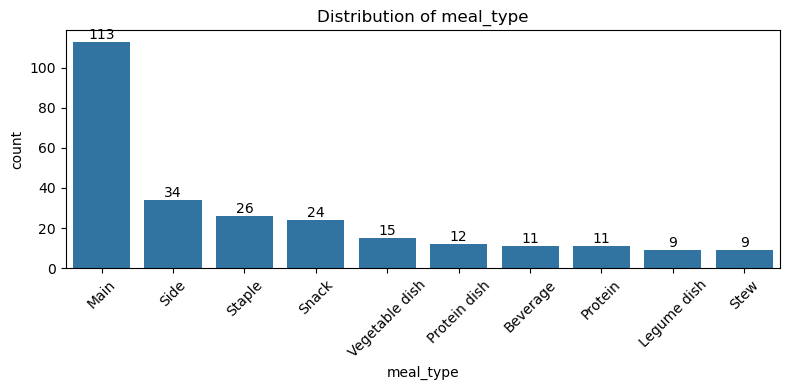

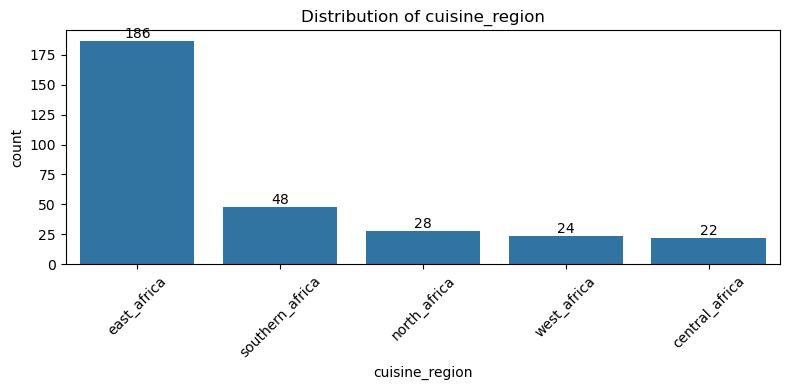

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ["meal_type", "cuisine_region"]

for col in categorical_cols:
    
    # Get value counts
    counts = final_african_recipes_df[col].value_counts()
    
    # If meal_type → limit to top 10
    if col == "meal_type":
        counts = counts.head(10)
    
    plt.figure(figsize=(8,4))
    
    ax = sns.countplot(
        data=final_african_recipes_df,
        x=col,
        order=counts.index
    )
    
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    
    # Add labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom'
        )
    
    plt.tight_layout()
    plt.show()

#### Insights from the chart above
From the charts, **East African cuisine dominates the dataset (186 recipes)**, far exceeding all other regions, which means any patterns learned from this data will be heavily influenced by East African foods.

Across meal types, **Main dishes are the most common (113)**, followed by **Side** and **Staple** meals, showing the dataset is strongly centered on full meals rather than beverages, proteins, or light dishes.

This indicates a **regional imbalance** and a **focus on main-course recipes**, which should be considered in any downstream analysis or modeling.


### Numerical Analysis

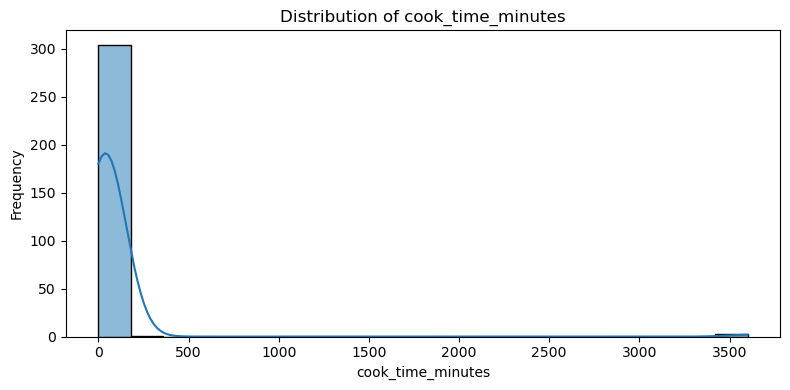

In [46]:
numeric_cols = ["cook_time_minutes"]

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        final_african_recipes_df[col],
        kde=True,
        bins=20
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

The cook-time distribution is **highly right-skewed**, with most recipes clustered at **short preparation times (roughly under 60 minutes)**.

A small number of recipes have **extremely long cooking times** (stretching into hundreds or even thousands of minutes), which likely correspond to entries such as multi-day preparations or converted ranges (e.g., “2–3 days”).

These extreme values act as **outliers** and can distort averages, so using the **median cook time** or capping very large values would give a more representative summary of typical cooking duration.


### Relationships
##### 1. Cook_time_minutes by cuisine region


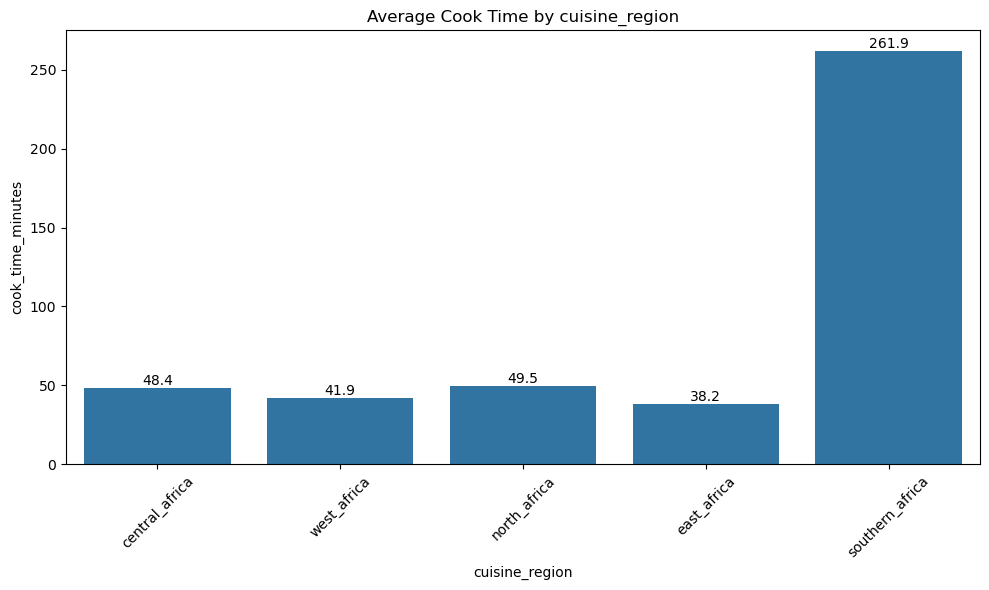

In [47]:
# Compute mean cook time per region and sort descending
region_means = (
    final_african_recipes_df
    .groupby("cuisine_region")["cook_time_minutes"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=final_african_recipes_df,
    x="cuisine_region",
    y="cook_time_minutes",
    order=region_means.index,
    errorbar=None
)

plt.title("Average Cook Time by cuisine_region")
plt.xticks(rotation=45)

# Add data labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

- Southern Africa is a clear outlier, with an average cook time of ~262 minutes, roughly 5–6 times longer than other regions, possibly due to slow-cooked dishes or data anomalies. 
- In contrast, North, Central, West, and East Africa cluster closely between 38–50 minutes, indicating most recipes require under an hour. East Africa has the shortest average cook time at ~38 minutes, suggesting a prevalence of quicker cooking methods like boiling or sautéing. 
- Overall, Southern Africa heavily drives variability in the dataset, while the other regions show relatively consistent cooking durations.

#### 2. Meal_type vs cook_time_minutes

C:\Users\eddyj\AppData\Local\Temp\ipykernel_12896\4042202679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cook_time.index, y=avg_cook_time.values, palette="viridis", dodge=False)


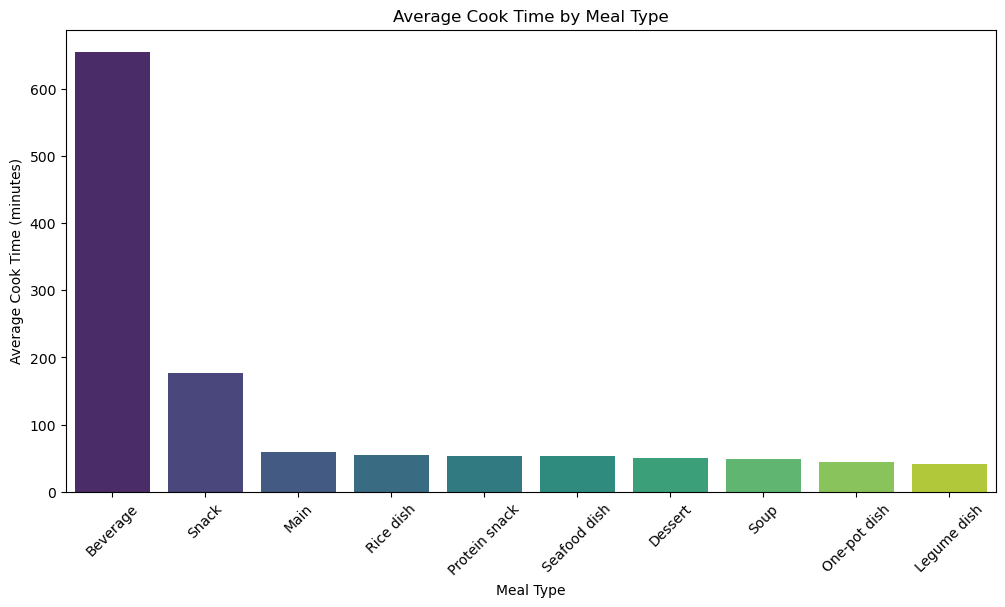

In [48]:
avg_cook_time = final_african_recipes_df.groupby("meal_type")["cook_time_minutes"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_cook_time.index, y=avg_cook_time.values, palette="viridis", dodge=False)
plt.title("Average Cook Time by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Average Cook Time (minutes)")
plt.xticks(rotation=45)
plt.show()

##### 3. Top Ingredients across Regions

<Figure size 1200x600 with 0 Axes>

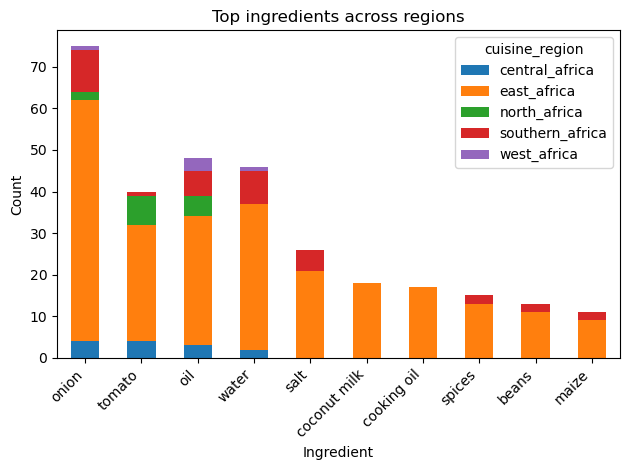

In [49]:
# ------------------------------------
# helper to explode comma-separated text
# ------------------------------------
def explode_text_col(df, col):
    return (
        df[[col, "cuisine_region"]]
        .dropna(subset=[col])
        .assign(
            item=lambda x: (
                x[col]
                .str.lower()
                .str.split(",")
            )
        )
        .explode("item")
        .assign(
            item=lambda x: x["item"].str.strip()
        )
        .query("item != ''")
    )


# =====================================================
# 1. Top ingredients across regions
# =====================================================

ingredients_long = explode_text_col(final_african_recipes_df, "core_ingredients")

ingredient_region_counts = (
    ingredients_long
        .groupby(["cuisine_region", "item"])
        .size()
        .reset_index(name="count")
)

# pick the top 10 ingredients overall
top_ingredients = (
    ingredient_region_counts
        .groupby("item")["count"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
)

plot_ing = ingredient_region_counts[
    ingredient_region_counts["item"].isin(top_ingredients)
]

pivot_ing = plot_ing.pivot(
    index="item",
    columns="cuisine_region",
    values="count"
).fillna(0)

plt.figure(figsize=(12, 6))
pivot_ing.sort_values(by=pivot_ing.columns.tolist(), ascending=False)\
          .plot(kind="bar", stacked=True)

plt.title("Top ingredients across regions")
plt.ylabel("Count")
plt.xlabel("Ingredient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


- Onions and tomatoes are the most widely used ingredients across African regions, with East Africa contributing the largest share. 
- Other staples like oil, water, and salt are also common but show more balanced distribution across regions. Southern Africa has noticeable contributions in several ingredients, while West and North Africa tend to have smaller counts for most top ingredients. 
- Overall, the chart highlights onions, tomatoes, and oil as core ingredients dominating African cuisine.